In [200]:
import osmnx as ox

G = ox.graph_from_place('Snohomish,Snohomish, Washington, USA', network_type='drive')

In [201]:
type(G)

networkx.classes.multidigraph.MultiDiGraph

In [202]:
len(G.nodes)

416

In [203]:
len(G.edges)

1057

In [204]:
list(G.edges(data=True))[0]

(50607534,
 50607543,
 {'osmid': 6132413,
  'highway': 'residential',
  'name': 'Terrace Avenue',
  'oneway': False,
  'reversed': False,
  'length': np.float64(113.30820412501359)})

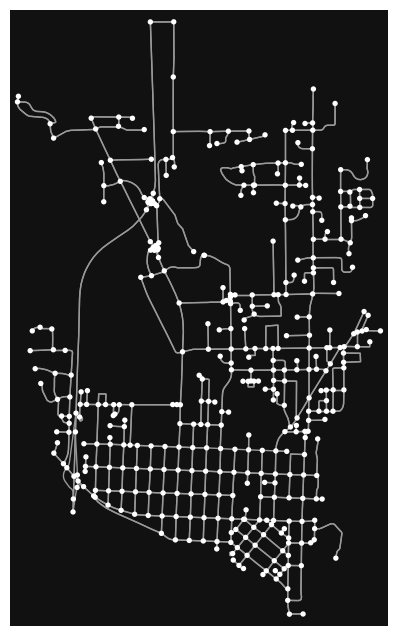

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [205]:
ox.plot_graph(G)


In [206]:
list(G.nodes(data=True))[0]

(50607534, {'y': 47.9334204, 'x': -122.0823321, 'street_count': 3})

In [207]:
ox.settings.elevation_url_template = (
    "https://api.opentopodata.org/v1/aster30m?locations={locations}"
)
G = ox.elevation.add_node_elevations_google(G, batch_size=100, pause=1)
G = ox.elevation.add_edge_grades(G)
print(list(G.nodes(data=True))[0])
print(list(G.edges(data=True))[0])

(50607534, {'y': 47.9334204, 'x': -122.0823321, 'street_count': 3, 'elevation': 62.0})
(50607534, 50607543, {'osmid': 6132413, 'highway': 'residential', 'name': 'Terrace Avenue', 'oneway': False, 'reversed': False, 'length': np.float64(113.30820412501359), 'grade': np.float64(0.05295291763145558), 'grade_abs': np.float64(0.05295291763145558)})


In [208]:
gdf_nodes, gdf_edges = ox.convert.graph_to_gdfs(G)
print(gdf_nodes.shape)
print(gdf_edges.shape)
gdf_edges.head()

(416, 6)
(1057, 15)


osmid      highway            name  oneway  \
u        v           key                                                    
50607534 50607543    0       6132413  residential  Terrace Avenue   False   
         50740099    0       6132413  residential  Terrace Avenue   False   
         12385935615 0    1339009305  residential             NaN   False   
50607543 50607534    0       6132413  residential  Terrace Avenue   False   
         50719959    0       6132413  residential  Terrace Avenue   False   

                         reversed      length     grade  grade_abs  \
u        v           key                                             
50607534 50607543    0      False  113.308204  0.052953   0.052953   
         50740099    0       True  236.807250  0.050674   0.050674   
         12385935615 0       True   67.615388  0.073948   0.073948   
50607543 50607534    0       True  113.308204 -0.052953   0.052953   
         50719959    0      False  159.779829  0.037552   0.037552   

                                                                   geometry  \
u        v           key                                                      
50607534 50607543    0    LINESTRING (-122.08233 47.93342, -122.08235 47...   
         50740099    0    LINESTRING (-122.08233 47.93342, -122.08231 47...   
         12385935615 0    LINESTRING (-122.08233 47.93342, -122.08156 47...   
50607543 50607534    0    LINESTRING (-122.08235 47.93444, -122.08233 47...   
         50719959    0    LINESTRING (-122.08235 47.93444, -122.08236 47...   

                         lanes maxspeed  ref bridge area junction  
u        v           key                                           
50607534 50607543    0     NaN      NaN  NaN    NaN  NaN      NaN  
         50740099    0     NaN      NaN  NaN    NaN  NaN      NaN  
         12385935615 0     NaN      NaN  NaN    NaN  NaN      NaN  
50607543 50607534    0     NaN      NaN  NaN    NaN  NaN      NaN  
         50719959    0     NaN      NaN  NaN    NaN  NaN      NaN

In [209]:
gdf_edges.index[0]

(np.int64(50607534), np.int64(50607543), np.int64(0))

In [210]:
gdf_edges['maxspeed'].isnull().sum()

np.int64(859)

In [211]:
print(gdf_edges['highway'].unique())
print(gdf_edges['highway'].isnull().sum())

<StringArray>
[  'residential',     'secondary',      'tertiary',  'primary_link',
       'primary',  'unclassified', 'living_street']
Length: 7, dtype: str
0


<Axes: >

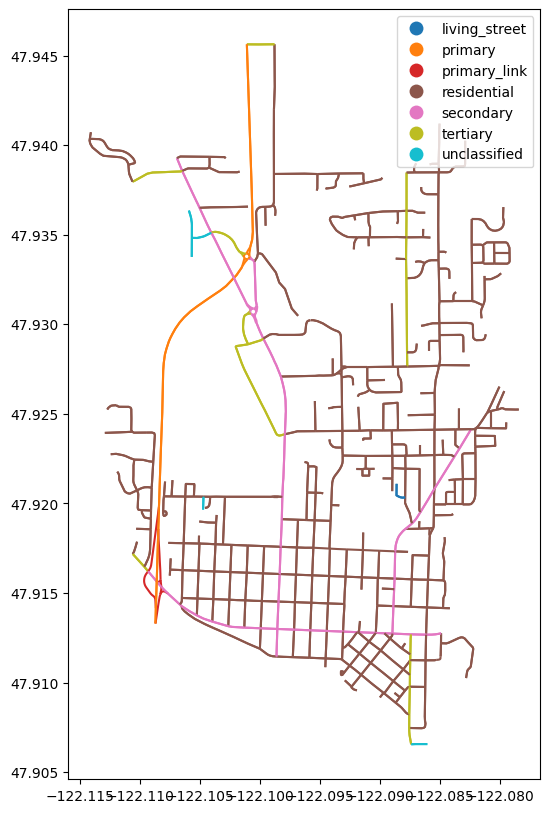

In [212]:
gdf_edges.plot(column='highway', figsize=(10, 10), legend=True)

In [213]:
gdf_edges['maxspeed'].dropna().unique()
gdf_edges['maxspeed'].dropna().head()

u         v           key
50632299  50651719    0      25 mph
          1499469272  0      25 mph
50633205  50796870    0      25 mph
          50651713    0      25 mph
50651713  50633205    0      25 mph
Name: maxspeed, dtype: str

In [223]:
default_speed = {
    'residential': '25',
    'secondary': '30',
    'tertiary': '35' ,
    'primary_link': '40',
    'primary': '45',
    'unclassified': '25',
    'living_street': '10'
}
gdf_edges['maxspeed'] = gdf_edges['maxspeed'].fillna(gdf_edges['highway'].map(default_speed))
gdf_edges['maxspeed'] = gdf_edges['maxspeed'].str.replace(' mph', '',regex=False)
gdf_edges['maxspeed'] = gdf_edges['maxspeed'].astype(int)
gdf_edges.head()

osmid      highway            name  oneway  \
u        v           key                                                    
50607534 50607543    0       6132413  residential  Terrace Avenue   False   
         50740099    0       6132413  residential  Terrace Avenue   False   
         12385935615 0    1339009305  residential             NaN   False   
50607543 50607534    0       6132413  residential  Terrace Avenue   False   
         50719959    0       6132413  residential  Terrace Avenue   False   

                         reversed      length     grade  grade_abs  \
u        v           key                                             
50607534 50607543    0      False  113.308204  0.052953   0.052953   
         50740099    0       True  236.807250  0.050674   0.050674   
         12385935615 0       True   67.615388  0.073948   0.073948   
50607543 50607534    0       True  113.308204 -0.052953   0.052953   
         50719959    0      False  159.779829  0.037552   0.037552   

                                                                   geometry  \
u        v           key                                                      
50607534 50607543    0    LINESTRING (-122.08233 47.93342, -122.08235 47...   
         50740099    0    LINESTRING (-122.08233 47.93342, -122.08231 47...   
         12385935615 0    LINESTRING (-122.08233 47.93342, -122.08156 47...   
50607543 50607534    0    LINESTRING (-122.08235 47.93444, -122.08233 47...   
         50719959    0    LINESTRING (-122.08235 47.93444, -122.08236 47...   

                         lanes  maxspeed  ref bridge area junction  curvature  
u        v           key                                                       
50607534 50607543    0     NaN        25  NaN    NaN  NaN      NaN   0.000000  
         50740099    0     NaN        25  NaN    NaN  NaN      NaN   0.000000  
         12385935615 0     NaN        25  NaN    NaN  NaN      NaN   0.342149  
50607543 50607534    0     NaN        25  NaN    NaN  NaN      NaN   0.000000  
         50719959    0     NaN        25  NaN    NaN  NaN      NaN   0.037195

In [224]:
gdf_edges['maxspeed'].isnull().sum()
gdf_edges['maxspeed'].dtype

dtype('int64')

In [216]:
import shapely as shp
import math
help(math.atan2)

Help on built-in function atan2 in module math:

atan2(y, x, /)
    Return the arc tangent (measured in radians) of y/x.

    Unlike atan(y/x), the signs of both x and y are considered.



In [217]:
from shapely import LineString


def compute_curvature(LineString):

    x, y = LineString.coords.xy
    currX = None
    currY = None
    bearing = 0
    prevbearing = None
    currbearing = None
    for n in range(len(x)):
        if n == 0:
            currX = x[n]
            currY = y[n]
        elif prevbearing is None:
            nextX = x[n]
            nextY = y[n]
            prevbearing = math.atan2(nextY - currY, nextX - currX)
            currX = nextX
            currY = nextY
        else:
            nextX = x[n]
            nextY = y[n]
            currbearing = math.atan2(nextY - currY, nextX - currX)
            diffBearing = abs(currbearing - prevbearing)
            bearing = diffBearing - (math.pi*2) + bearing if diffBearing > math.pi else diffBearing + bearing
            prevbearing = currbearing
            currX = nextX
            currY = nextY

    return bearing
test_geom = gdf_edges['geometry'].iloc[0]
print(test_geom)
compute_curvature(test_geom)
for x in gdf_edges['geometry']:
    print(compute_curvature(x))
        

LINESTRING (-122.0823321 47.9334204, -122.0823538 47.9344393)
0
0
0.3421488007502699
0
0.037194583697084616
0.4028273909481441
0.1353860417644055
-0.048488422841932444
0.16199388787551217
0.13538604176440572
0.00024615702582092905
-0.06630962476429936
0.08938916978312172
0.48472142730502876
0.3722457645987287
0.29566711862965533
0.2734102685241875
0.2274032859792129
3.391655904385126
0.05561150311186491
0
0.2459091861586824
0.001521202842029279
0
4.720083926601504e-05
2.949266677737268
0.030453337096118638
0.030061973746978055
0.08472585804327193
0
0.0007635530127945156
0.6744853964401389
1.6362989983300147
1.368848424450557
0.2082997699608562
0
0.142583053500269
0.0002904278782542846
0.1118117466475117
0.5814164013471437
0.05561150311186491
1.9035629984662912
0.6983581440533206
0.37224576459872916
0.2767029236630306
0.1177308637671417
0.059849407397063514
1.2569974754172628
1.6245299692386275
0.00026113663667048925
1.256997475417263
0.2545775442255126
0.35463918915783416
0.25457754422

In [218]:
gdf_edges['curvature'] = gdf_edges['geometry'].apply(compute_curvature)
gdf_edges['curvature'].idxmax()

(np.int64(7211030053), np.int64(7211030053), np.int64(0))

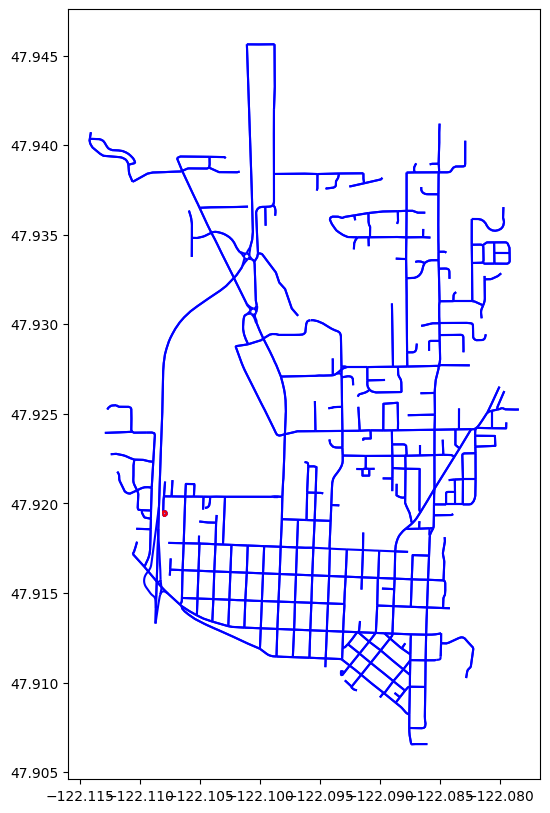

In [219]:
import matplotlib.pyplot as plt
max_curve =gdf_edges[gdf_edges['curvature'] == gdf_edges['curvature'].max()]
fig, ax = plt.subplots(figsize=(10, 10))
gdf_edges.plot(ax =ax, color='blue', legend=True)
max_curve.plot(ax=ax, color='red', label='Max Curvature')
plt.show()




<Axes: >

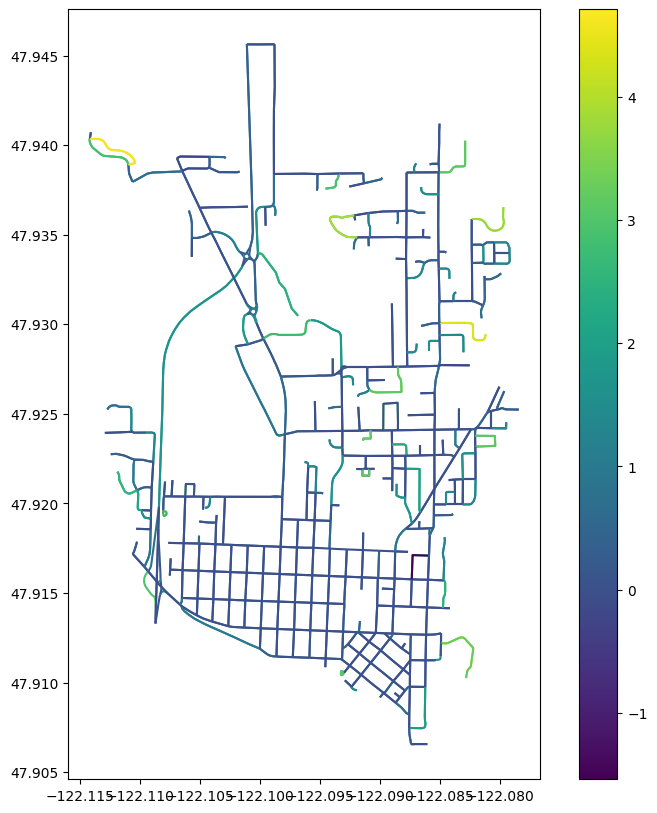

In [220]:
gdf_edges.plot(column='curvature', figsize=(10, 10), legend=True)

In [221]:
gdf_nodes.head()

,y,x,street_count,elevation,highway,geometry
osmid,,,,,,
50607534,47.933420,-122.082332,3,62.0,NaN,POINT (-122.08233 47.93342)
50607543,47.934439,-122.082354,3,68.0,NaN,POINT (-122.08235 47.93444)
50617706,47.928093,-122.093932,1,31.0,NaN,POINT (-122.09393 47.92809)
50617714,47.927151,-122.093925,3,36.0,NaN,POINT (-122.09393 47.92715)
50628349,47.918590,-122.086730,3,15.0,NaN,POINT (-122.08673 47.91859)


In [222]:
gdf_edges.head()

osmid      highway            name  oneway  \
u        v           key                                                    
50607534 50607543    0       6132413  residential  Terrace Avenue   False   
         50740099    0       6132413  residential  Terrace Avenue   False   
         12385935615 0    1339009305  residential             NaN   False   
50607543 50607534    0       6132413  residential  Terrace Avenue   False   
         50719959    0       6132413  residential  Terrace Avenue   False   

                         reversed      length     grade  grade_abs  \
u        v           key                                             
50607534 50607543    0      False  113.308204  0.052953   0.052953   
         50740099    0       True  236.807250  0.050674   0.050674   
         12385935615 0       True   67.615388  0.073948   0.073948   
50607543 50607534    0       True  113.308204 -0.052953   0.052953   
         50719959    0      False  159.779829  0.037552   0.037552   

                                                                   geometry  \
u        v           key                                                      
50607534 50607543    0    LINESTRING (-122.08233 47.93342, -122.08235 47...   
         50740099    0    LINESTRING (-122.08233 47.93342, -122.08231 47...   
         12385935615 0    LINESTRING (-122.08233 47.93342, -122.08156 47...   
50607543 50607534    0    LINESTRING (-122.08235 47.93444, -122.08233 47...   
         50719959    0    LINESTRING (-122.08235 47.93444, -122.08236 47...   

                         lanes maxspeed  ref bridge area junction  curvature  
u        v           key                                                      
50607534 50607543    0     NaN       25  NaN    NaN  NaN      NaN   0.000000  
         50740099    0     NaN       25  NaN    NaN  NaN      NaN   0.000000  
         12385935615 0     NaN       25  NaN    NaN  NaN      NaN   0.342149  
50607543 50607534    0     NaN       25  NaN    NaN  NaN      NaN   0.000000  
         50719959    0     NaN       25  NaN    NaN  NaN      NaN   0.037195